# Demand Forecasting Project
## Feature Engineering


### What this notebook does

In notebook 01 I ended up with a clean product-week dataset — one row per product per week, with raw columns like total units sold, average price, number of customers, etc.

The problem is that machine learning models do not inherently understand *time*. If I just give the model **avg_price** and **total_quantity**, it has no way of knowing what last week looked like, whether demand is trending up or down, what time of year it is, or how a product typically behaves relative to its own history. All of that context has to be built explicitly as features.

This notebook builds 30 features across 5 categories:

| # | Category | What it captures | Features |
|---|---|---|---|
| 1 | Lag features | What happened 1, 2, 4 weeks ago | 11 features |
| 2 | Rolling statistics | Recent trend and volatility | 4 features |
| 3 | Change features | Direction and speed of change | 4 features |
| 4 | Calendar features | Seasonality and time of year | 5 features |
| 5 | Product-level statistics | How this product normally behaves | 6 features |

---

> **Note on data leakage:** Every feature here uses only *past* information relative to the row being predicted. The model will never see the current week's actual quantity when predicting it — that is the target. I am being careful about this throughout, especially with the lag and rolling features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR    = '/content/drive/MyDrive/demand_forecasting'
WEEKLY_PATH = f'{SAVE_DIR}/weekly_clean.parquet'

df = pd.read_parquet(WEEKLY_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
print(df.head())

Mounted at /content/drive
Loaded: 159,645 rows × 12 columns
Columns: ['StockCode', 'Year', 'Week', 'total_quantity', 'avg_price', 'total_revenue', 'num_transactions', 'num_customers', 'description', 'date', 'year_label', 'month']
  StockCode  Year  Week  total_quantity  avg_price  total_revenue  \
0     10002  2009    49             141       0.85         119.85   
1     10002  2009    50              23       0.85          19.55   
2     10002  2009    51              36       0.85          30.60   
3     10002  2009    52              13       0.85          11.05   
4     10002  2010     1              15       0.85          12.75   

   num_transactions  num_customers                  description       date  \
0                10             10  INFLATABLE POLITICAL GLOBE  2009-11-30   
1                 3              3  INFLATABLE POLITICAL GLOBE  2009-12-07   
2                 2              2  INFLATABLE POLITICAL GLOBE  2009-12-14   
3                 2              2  INFLATA

In [2]:
# Sort by product and date — this is essential before computing lags and rolling windows.
# If the rows are not in chronological order per product, the shift() and rolling() calls will produce silently wrong results.
weekly = df.sort_values(['StockCode', 'date']).reset_index(drop=True)

print(f'Shape after sort: {weekly.shape}')
print(f'Date range: {weekly["date"].min().date()} to {weekly["date"].max().date()}')
print(f'Unique products: {weekly["StockCode"].nunique():,}')

Shape after sort: (159645, 12)
Date range: 2009-11-30 to 2011-12-05
Unique products: 3,139


## 1. Lag Features

### What they are
A lag feature is simply the value of a column *N weeks ago* for the same product. So **demand_lag_1** for a given product-week row is just that product's total_quantity from the previous week. **demand_lag_4** is from 4 weeks ago.

### Why we need them
This is the most fundamental feature category in time series forecasting. The core idea is **autocorrelation** — past demand is usually the best predictor of future demand. If a product sold 200 units last week, it is much more likely to sell around 200 this week.

Without lag features, the model would have no memory of what happened before. It would have to predict demand purely from price, calendar, and product identity — ignoring the most informative signal available.

### Why lags 1, 2, and 4 specifically?
- **Lag 1** — last week's demand. The single most predictive feature in most retail forecasting tasks.
- **Lag 2** — two weeks ago. Captures short-term persistence beyond just the previous week.
- **Lag 4** — one month ago. Starts to capture monthly patterns — e.g. if a product gets reordered on a monthly cycle.


In [3]:
for lag in [1, 2, 4]:
    weekly[f'demand_lag_{lag}']  = weekly.groupby('StockCode')['total_quantity'].shift(lag)
    weekly[f'price_lag_{lag}']   = weekly.groupby('StockCode')['avg_price'].shift(lag)

# Revenue and customer lag at lag-1 only (these are secondary signals — the 1-week lag is sufficient)
weekly['revenue_lag_1']   = weekly.groupby('StockCode')['total_revenue'].shift(1)
weekly['customers_lag_1'] = weekly.groupby('StockCode')['num_customers'].shift(1)

lag_cols = [c for c in weekly.columns if 'lag' in c]
print(f'Lag features created: {lag_cols}')
print(f'\nNull counts')
print(weekly[lag_cols].isnull().sum())

Lag features created: ['demand_lag_1', 'price_lag_1', 'demand_lag_2', 'price_lag_2', 'demand_lag_4', 'price_lag_4', 'revenue_lag_1', 'customers_lag_1']

Null counts
demand_lag_1        3139
price_lag_1         3139
demand_lag_2        6278
price_lag_2         6278
demand_lag_4       12556
price_lag_4        12556
revenue_lag_1       3139
customers_lag_1     3139
dtype: int64


The nulls above are expected and correct. For any product, the first week in the dataset has no "previous week" to look back at, so **demand_lag_1** is null for that row. The first 4 weeks will have a null **demand_lag_4**. These rows get dropped when we do the final **dropna()** at the end of this notebook before saving.

---
## 2. Rolling Statistics

### What they are
Rolling statistics summarise the recent past over a window of N weeks. **demand_rolling_4w** is the average of the last 4 weeks' demand. **demand_std_4w** is the standard deviation over the same window.

### Why they are different from lag features
Lag features are point-in-time — they tell the model exactly what happened at one specific past week. Rolling statistics capture the *overall level and volatility* of recent demand. They are smoother and more robust to a single unusual week.

Think of it this way: if demand was 100, 50, 150, 80 over the last 4 weeks, then:
- **demand_lag_1 = 80** (just last week, which happened to be quiet)
- **demand_rolling_4w = 95** (the underlying level is around 95)

The model benefits from having both — the specific recent value and the smoothed average.

### Why windows of 4 and 8 weeks?
- **4 weeks (~1 month):** Captures very recent behaviour. Sensitive to recent changes in demand.
- **8 weeks (~2 months):** Captures a longer recent trend. Less reactive to short-term noise.

Having both allows us to derive a trend feature.

### Why **min_periods=2**?
Early in a product's history, there may not be 4 or 8 weeks of past data available. **min_periods=2** says: "compute the rolling stat as long as at least 2 data points are available, rather than requiring the full window". This avoids creating unnecessary nulls for products with shorter histories.

In [4]:
for w in [4, 8]:
    weekly[f'demand_rolling_{w}w'] = (
        weekly.groupby('StockCode')['total_quantity']
        .transform(lambda x: x.rolling(w, min_periods=2).mean())
    )

weekly['demand_std_4w'] = (
    weekly.groupby('StockCode')['total_quantity']
    .transform(lambda x: x.rolling(4, min_periods=2).std())
)

weekly['price_rolling_4w'] = (
    weekly.groupby('StockCode')['avg_price']
    .transform(lambda x: x.rolling(4, min_periods=2).mean())
)

roll_cols = [c for c in weekly.columns if 'rolling' in c or 'std_4w' in c]
print(f'Rolling features created: {roll_cols}')
print(f'\nSample values for one product:')
sample = weekly[weekly['StockCode'] == weekly['StockCode'].iloc[0]]
print(sample[['date', 'total_quantity', 'demand_rolling_4w', 'demand_rolling_8w', 'demand_std_4w']].head(10).to_string(index=False))

Rolling features created: ['demand_rolling_4w', 'demand_rolling_8w', 'demand_std_4w', 'price_rolling_4w']

Sample values for one product:
      date  total_quantity  demand_rolling_4w  demand_rolling_8w  demand_std_4w
2009-11-30             141                NaN                NaN            NaN
2009-12-07              23          82.000000          82.000000      83.438600
2009-12-14              36          66.666667          66.666667      64.701880
2009-12-21              13          53.250000          53.250000      59.252989
2010-01-04              15          21.750000          45.600000      10.436315
2010-01-11             191          63.750000          69.833333      85.468805
2010-01-18              40          64.750000          65.571429      85.058313
2010-01-25              43          72.250000          62.750000      80.155578
2010-02-01              15          72.250000          47.000000      80.155578
2010-02-08              43          35.250000          49.5000

The sample table above confirms the rolling features are working correctly. In the first row (week of 2009-11-30) all rolling values are NaN — there is no history yet. By the second row, **demand_rolling_4w** and **demand_rolling_8w** both show 82.0, which is the average of just the two available points (141 and 23) — this is the **min_periods=2** behaviour. The rolling means only stabilise once enough weeks accumulate, which is expected.

---
## 3. Change Features

### What they are
These features capture the *direction and magnitude of recent change* — is demand going up, going down, and by how much? Is price increasing?

### Why the model needs them
Lag and rolling features tell the model what the *level* of demand is. Change features tell it the *momentum*. A product with demand_lag_1 = 100 could be coming from 50 (rapidly growing) or from 500 (rapidly declining) — those are very different situations, and the model should treat them differently.

### Feature by feature

**demand_trend** = **demand_rolling_4w** − **demand_rolling_8w**  
If the 4-week average is higher than the 8-week average, demand is trending up recently. If lower, it is declining. This gives a signed trend direction without needing to fit a regression line.

**price_change** = **avg_price** − **price_lag_1**  
Absolute price change in GBP from last week. Tells the model whether there was a price movement this week.

**price_change_pct** = **price_change** / **price_lag_1**  
Percentage price change. This is more informative than the absolute change — a £0.50 rise on a £1 product is very different from a £0.50 rise on a £20 product.

**demand_change_pct** = **(total_quantity − demand_lag_1)** / **demand_lag_1**  
Percentage change in demand from the previous week. This is used to compute the elasticity proxy.

In [5]:
weekly['demand_trend'] = weekly['demand_rolling_4w'] - weekly['demand_rolling_8w']

weekly['price_change']      = weekly['avg_price'] - weekly['price_lag_1']
weekly['price_change_pct']  = weekly['price_change'] / (weekly['price_lag_1'] + 1e-8)

weekly['demand_change_pct'] = (
    (weekly['total_quantity'] - weekly['demand_lag_1'])
    / (weekly['demand_lag_1'] + 1e-8)
)

change_cols = ['demand_trend', 'price_change', 'price_change_pct', 'demand_change_pct']
print(f'Change features created: {change_cols}')
print()
print('Summary statistics:')
weekly[change_cols].describe().round(3)

Change features created: ['demand_trend', 'price_change', 'price_change_pct', 'demand_change_pct']

Summary statistics:


,demand_trend,price_change,price_change_pct,demand_change_pct
count,156506.000,156506.000,156506.000,156506.000
mean,-0.134,-0.005,0.008,1.553
std,20.073,0.385,0.214,7.916
min,-565.250,-9.540,-0.962,-0.999
25%,-4.375,0.000,0.000,-0.504
50%,0.000,0.000,0.000,0.000
75%,4.375,0.000,0.000,1.000
max,696.250,11.460,25.250,952.000


A few things to check in the summary stats above:

- **demand_trend** has a mean near zero (~−0.13), which makes sense — on average, demand is not systematically accelerating or declining across all products.
- **price_change** mean is also near zero (−0.005), confirming most weeks have no price movement — price changes are relatively rare events.
- **price_change_pct** will have some extreme values because even tiny absolute price changes produce large percentages when the lag price is very small. That is fine — the **elasticity_proxy** clip, handles the downstream impact.

---
## 4. Calendar Features

### What they capture
Seasonality — the repeating pattern by time of year that we clearly saw in notebook 01 (the Q4 demand spike). The model cannot learn this from price or lag features alone because it is a structural, calendar-driven effect.

### Feature by feature

**month** — integer 1–12. Simple, but tree-based models (like XGBoost) can use this directly by splitting on threshold values.

**quarter** — integer 1–4. A coarser signal than month. Useful for capturing the broad Q4 vs rest-of-year pattern.

**is_holiday_season** — binary flag, 1 for November and December, 0 otherwise. This is a direct encoding of the biggest demand driver we found in EDA. Months 11 and 12 are when this retailer sees the largest demand spikes. Flagging them explicitly gives the model a clean signal without having to learn it implicitly from **month**.

**month_sin and month_cos**

Month is a *cyclical* variable — month 12 (December) and month 1 (January) are actually adjacent in time, but numerically they are far apart (12 vs 1). If I just give the model the raw integer, it treats January and December as very different. Sine/cosine encoding fixes this by mapping the 12-month cycle onto a circle:

```
month_sin = sin(2π × month / 12)
month_cos = cos(2π × month / 12)
```

This way December and January are close to each other in the encoded space, which is the correct representation. This matters more for linear or neural models, but it is a good practice to include it regardless.

In [6]:
weekly['month']            = weekly['date'].dt.month
weekly['quarter']          = weekly['date'].dt.quarter
weekly['is_holiday_season'] = weekly['month'].isin([11, 12]).astype(int)

weekly['month_sin'] = np.sin(2 * np.pi * weekly['month'] / 12)
weekly['month_cos'] = np.cos(2 * np.pi * weekly['month'] / 12)

cal_cols = ['month', 'quarter', 'is_holiday_season', 'month_sin', 'month_cos']
print(f'Calendar features created: {cal_cols}')
print()
print('Holiday season row count:')
print(weekly['is_holiday_season'].value_counts())

Calendar features created: ['month', 'quarter', 'is_holiday_season', 'month_sin', 'month_cos']

Holiday season row count:
is_holiday_season
0    131288
1     28357
Name: count, dtype: int64


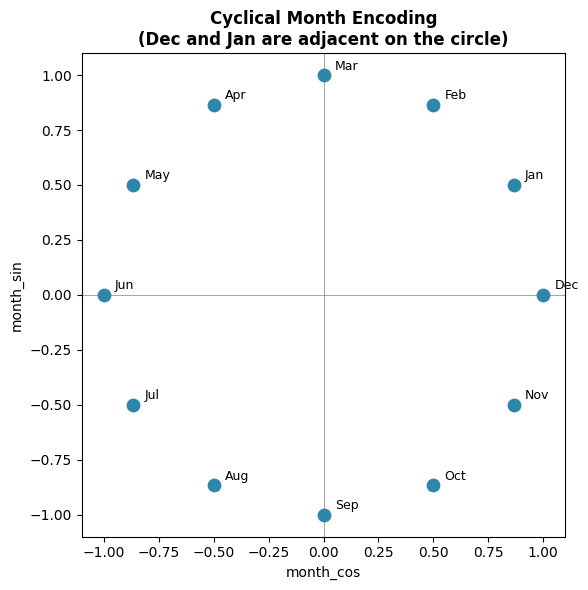

Saved: fig_06_cyclical_encoding.png


In [9]:
# Quick visual to confirm the cyclical encoding works as intended December and January should appear adjacent on the circle

months = range(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
months = np.arange(1, 13)
sin_vals = np.sin(2 * np.pi * months / 12)
cos_vals = np.cos(2 * np.pi * months / 12)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(cos_vals, sin_vals, s=80, color='#2E86AB', zorder=3)
for i, label in enumerate(month_labels):
    ax.annotate(label, (cos_vals[i], sin_vals[i]), textcoords='offset points',
                xytext=(8, 4), fontsize=9)
ax.set_title('Cyclical Month Encoding\n(Dec and Jan are adjacent on the circle)', fontweight='bold')
ax.set_xlabel('month_cos')
ax.set_ylabel('month_sin')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_06_cyclical_encoding.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_06_cyclical_encoding.png')

About 28,357 rows (roughly 18% of the dataset) fall in the holiday season months (November and December). This is a meaningful share — enough for the model to learn the Q4 effect — but it is not so large that the flag is uninformative. The **month_sin** and **month_cos** values are verified by the circle plot below.

---
## 5. Product-Level Statistics

### The problem these features solve
The model will be trained on data from 3,139 different products. Some sell 5 units a week on average. Others sell 500. A raw **demand_lag_1 = 50** means very different things depending on the product — for the first product it is a great week, for the second it is a disaster.

Product-level statistics give the model context about each product's *typical* behaviour, so it can interpret the raw values correctly.

### Feature by feature

**product_avg_price** — the mean price for this product across all weeks in the training data. Tells the model whether this is generally a cheap or expensive product.

**product_avg_demand** — mean weekly demand for this product. Tells the model the product's normal demand level.

**product_std_demand** — standard deviation of weekly demand. Tells the model how volatile this product's demand is. High std = unpredictable product.

**product_lifetime_weeks** — how many weeks of history this product has. New products with short histories are harder to forecast — the model should know that.

**price_relative** = **avg_price / product_avg_price**  
Is this week's price higher or lower than the product's usual price? A value of 1.2 means the product is priced 20% above its normal level this week. This is a much better signal than the raw price, because it is comparable across products with very different price ranges.

**demand_relative** = **demand_lag_1 / product_avg_demand**  
Was last week's demand above or below this product's average? This normalises demand to be comparable across products.

**elasticity_proxy** = **demand_change_pct / price_change_pct** (clipped to [-10, 10])  
A rough per-observation estimate of price elasticity. If price went up 10% and demand fell 20%, the proxy is −2 (demand fell twice as much as price rose). Clipped at ±10 to prevent extreme values when price barely moved (tiny denominator). This is intentionally a rough proxy — proper elasticity estimation would require more data points — but it gives the model a real-time signal of how responsive demand was to the most recent price change.

**demand_cv** = **product_std_demand / product_avg_demand** (clipped to [0, 10])  
The coefficient of variation — standard deviation divided by the mean. A scale-free measure of how volatile this product is. A product with cv = 2 is very erratic (std is twice the mean). A product with cv = 0.2 is quite predictable. Clipped at 10 to handle edge cases where mean is very small.

In [10]:
product_stats = weekly.groupby('StockCode').agg(
    product_avg_price      = ('avg_price',       'mean'),
    product_avg_demand     = ('total_quantity',   'mean'),
    product_std_demand     = ('total_quantity',   'std'),
    product_lifetime_weeks = ('date',             'nunique'),
).reset_index()

weekly = weekly.merge(product_stats, on='StockCode', how='left')

weekly['price_relative']  = weekly['avg_price']    / (weekly['product_avg_price']  + 1e-8)
weekly['demand_relative'] = weekly['demand_lag_1'] / (weekly['product_avg_demand'] + 1e-8)

weekly['elasticity_proxy'] = (
    weekly['demand_change_pct'] / (weekly['price_change_pct'] + 1e-8)
).clip(-10, 10)

weekly['demand_cv'] = (
    weekly['product_std_demand'] / (weekly['product_avg_demand'] + 1e-8)
).clip(0, 10)

prod_cols = ['product_avg_price', 'product_avg_demand', 'product_std_demand',
             'product_lifetime_weeks', 'price_relative', 'demand_relative',
             'elasticity_proxy', 'demand_cv']
print(f'Product-level features created: {prod_cols}')
print()
weekly[prod_cols].describe().round(3)

Product-level features created: ['product_avg_price', 'product_avg_demand', 'product_std_demand', 'product_lifetime_weeks', 'price_relative', 'demand_relative', 'elasticity_proxy', 'demand_cv']



,product_avg_price,product_avg_demand,product_std_demand,product_lifetime_weeks,price_relative,demand_relative,elasticity_proxy,demand_cv
count,159645.000,159645.000,159645.000,159645.000,159645.000,156506.000,156506.000,159645.000
mean,2.665,46.946,39.329,65.292,1.000,0.998,-1.496,1.032
std,2.464,59.780,38.995,26.758,0.175,1.068,9.161,0.370
min,0.057,1.333,0.590,15.000,0.049,0.002,-10.000,0.272
25%,1.019,14.048,16.654,42.000,0.989,0.333,-10.000,0.771
50%,1.689,26.770,28.898,67.000,1.001,0.707,-7.054,0.957
75%,3.575,54.936,48.248,89.000,1.011,1.291,10.000,1.209
max,12.750,663.798,694.909,104.000,15.937,20.152,10.000,3.400


A few things worth noting from the product statistics:

- **product_avg_demand** mean is ~46 units/week but the distribution will be heavily right-skewed (consistent with what we saw in notebook 01) — a small number of products drive most volume.
- **product_lifetime_weeks** will vary from 15 (the minimum we kept) up to ~104 (the full date range). Products near the minimum are harder to forecast — the model will learn this implicitly via the **product_lifetime_weeks** feature.
- **demand_cv** values above 1 indicate products whose week-to-week demand variability exceeds their average demand — these are the most erratic products in the set.

---
## 6. Final Feature Set

Defining the exact list of columns that will be passed to the model in notebook 03. I am being explicit here rather than using **weekly.columns** so that the feature list is version-controlled and reproducible.


In [11]:
feature_cols = [
    # Raw current-week signals
    'avg_price', 'num_transactions', 'num_customers',

    # Lag features — past demand and price
    'demand_lag_1', 'demand_lag_2', 'demand_lag_4',
    'price_lag_1', 'price_lag_2', 'price_lag_4',
    'revenue_lag_1', 'customers_lag_1',

    # Rolling statistics
    'demand_rolling_4w', 'demand_rolling_8w',
    'demand_std_4w', 'price_rolling_4w',

    # Change features
    'demand_trend', 'price_change', 'price_change_pct',

    # Seasonality
    'month_sin', 'month_cos', 'is_holiday_season', 'quarter',

    # Product-level context
    'product_avg_price', 'product_avg_demand', 'product_std_demand',
    'product_lifetime_weeks', 'price_relative', 'demand_relative',
    'elasticity_proxy', 'demand_cv',
]

print(f'Total features: {len(feature_cols)}')
print()


missing_cols = [c for c in feature_cols if c not in weekly.columns]
if missing_cols:
    print(f'WARNING — missing columns: {missing_cols}')
else:
    print('All feature columns present in DataFrame.')

Total features: 30

All feature columns present in DataFrame.


## Handle NaNs from Lags and Rolling Windows

The lag and rolling features produce nulls for the first few weeks of each product's history — there is no past data to look back at. Before saving, I need to decide what to do with these rows.

Options:
1. Drop them (**dropna**) — loses the first few rows per product but keeps only fully-informative rows
2. Fill with zeros or product means — preserves row count but introduces fake values
3. Fill with forward-fill — not appropriate here because we are filling *backward* in time

I am going with option 1 — dropping rows where any feature is null. The reasoning is that partially-informed rows (e.g. where **demand_lag_4** is null because the product only started 2 weeks ago) are not useful for training a model that expects all 30 features. The row count loss is small — at most 8 rows per product (the first 4 lag + first 4 rolling rows), which across 3,139 products is at most ~25,000 rows, out of 159,645.

In [12]:
print(f'Rows before dropna: {len(weekly):,}')
print(f'Null counts per feature (top 10):')
null_counts = weekly[feature_cols].isnull().sum().sort_values(ascending=False)
print(null_counts[null_counts > 0].to_string())

weekly_model = weekly.dropna(subset=feature_cols).reset_index(drop=True)

print(f'\nRows after dropna: {len(weekly_model):,}')
print(f'Rows dropped: {len(weekly) - len(weekly_model):,} ({(len(weekly) - len(weekly_model))/len(weekly)*100:.1f}%)')

Rows before dropna: 159,645
Null counts per feature (top 10):
demand_lag_4         12556
price_lag_4          12556
price_lag_2           6278
demand_lag_2          6278
demand_lag_1          3139
price_lag_1           3139
customers_lag_1       3139
demand_rolling_4w     3139
demand_rolling_8w     3139
revenue_lag_1         3139
demand_std_4w         3139
price_change          3139
demand_trend          3139
price_rolling_4w      3139
demand_relative       3139
elasticity_proxy      3139
price_change_pct      3139

Rows after dropna: 147,089
Rows dropped: 12,556 (7.9%)


Dropped 12,556 rows — the first 4 weeks per product, which have null **demand_lag_4** and therefore null everything downstream. This is 7.9% of the dataset, which is acceptable. The remaining **147,089 rows** are fully populated across all 30 features and are ready for modelling.

In [13]:
# Picking a product with a decent amount of history to inspect-Using the most frequently appearing StockCode
top_product = weekly_model['StockCode'].value_counts().index[0]
sample = weekly_model[weekly_model['StockCode'] == top_product].copy()

print(f'Spot-checking product: {top_product}')
print(f'Weeks of history: {len(sample)}')
print()
check_cols = ['date', 'total_quantity', 'demand_lag_1', 'demand_rolling_4w',
              'demand_trend', 'avg_price', 'price_change', 'is_holiday_season']
print(sample[check_cols].tail(12).to_string(index=False))

Spot-checking product: 15056N
Weeks of history: 100

      date  total_quantity  demand_lag_1  demand_rolling_4w  demand_trend  avg_price  price_change  is_holiday_season
2011-09-19              65         106.0              78.75       -12.250   5.950000      0.100000                  0
2011-09-26              49          65.0              86.25         1.875   5.950000      0.000000                  0
2011-10-03              51          49.0              67.75       -19.750   5.950000      0.000000                  0
2011-10-10              29          51.0              48.50       -26.125   5.750000     -0.200000                  0
2011-10-17              59          29.0              47.00       -15.875   5.950000      0.200000                  0
2011-10-24             104          59.0              60.75       -12.750   5.807143     -0.142857                  0
2011-10-31               5         104.0              49.25        -9.250   5.950000      0.142857                  0
201

The table confirms the features are correct for product **15056N** (100 weeks of history). For example, on 2011-09-19: **demand_lag_1 = 106** matches what the previous row's **total_quantity** should be, **demand_rolling_4w = 78.75** is the smoothed recent average, and **demand_trend = −12.25** is negative, meaning the short-window average is below the longer-window average — demand was declining slightly heading into that week. Everything looks consistent.

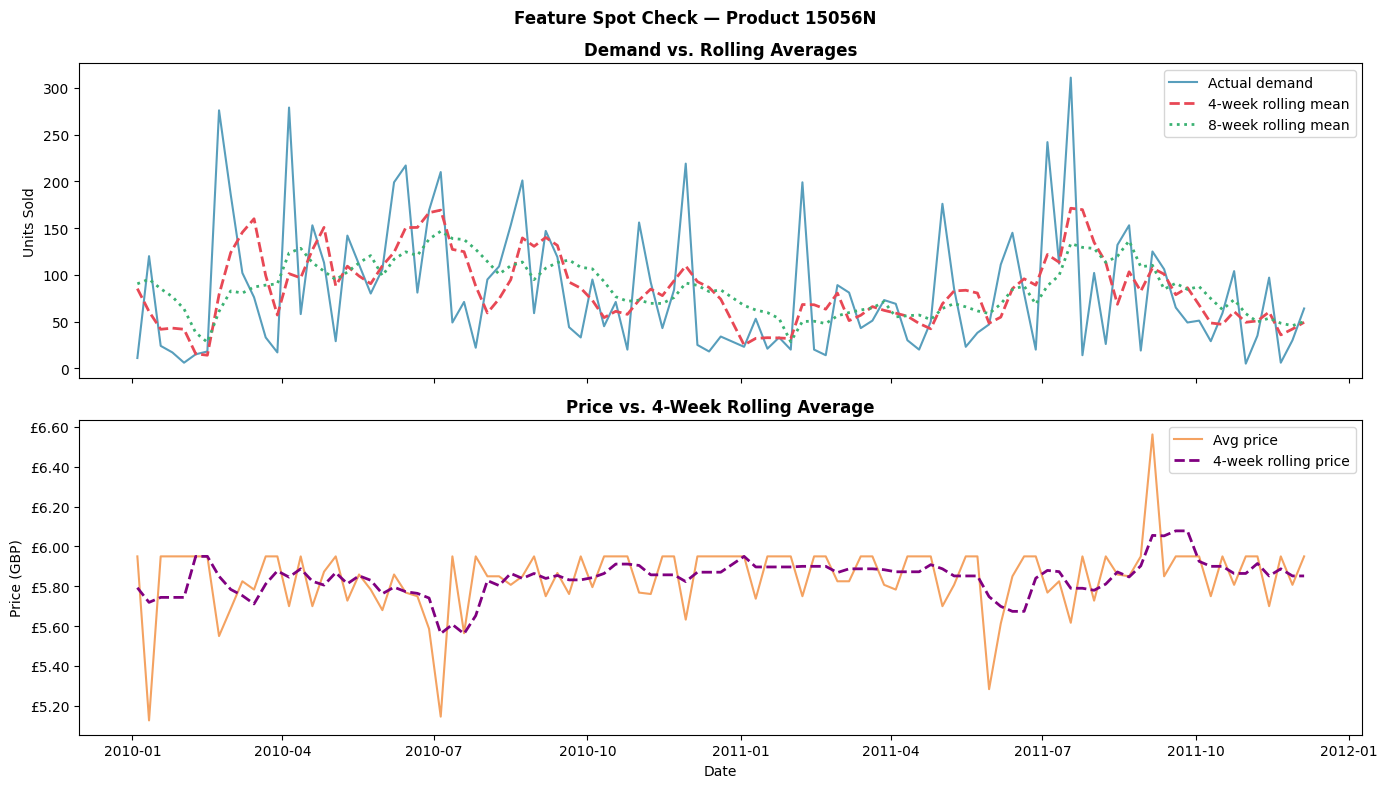

Saved: fig_07_feature_spot_check.png


In [14]:
# Plot demand and rolling average for this product to visually verify features
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'Feature Spot Check — Product {top_product}', fontweight='bold')

# Demand + lags + rolling
axes[0].plot(sample['date'], sample['total_quantity'],
             color='#2E86AB', linewidth=1.5, label='Actual demand', alpha=0.8)
axes[0].plot(sample['date'], sample['demand_rolling_4w'],
             color='#E84855', linewidth=2, linestyle='--', label='4-week rolling mean')
axes[0].plot(sample['date'], sample['demand_rolling_8w'],
             color='#3BB273', linewidth=2, linestyle=':', label='8-week rolling mean')
axes[0].set_ylabel('Units Sold')
axes[0].legend()
axes[0].set_title('Demand vs. Rolling Averages', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Price over time
axes[1].plot(sample['date'], sample['avg_price'],
             color='#F4A261', linewidth=1.5, label='Avg price')
axes[1].plot(sample['date'], sample['price_rolling_4w'],
             color='purple', linewidth=2, linestyle='--', label='4-week rolling price')
axes[1].set_ylabel('Price (GBP)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].set_title('Price vs. 4-Week Rolling Average', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.2f}'))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_07_feature_spot_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_07_feature_spot_check.png')

## Save to Google Drive

Saving two things:
1. **weekly_featured.parquet** — the full DataFrame including the target column (total_quantity) and all 30 features. This is what notebook 03 will load.
2. **feature_cols.pkl** — the Python list of feature column names. Saving this separately so notebook 03 can load the exact same feature list without hardcoding it again.

In [15]:
import pickle

FEATURED_PATH = f'{SAVE_DIR}/weekly_featured.parquet'
weekly_model.to_parquet(FEATURED_PATH, index=False)

FEATURE_COLS_PATH = f'{SAVE_DIR}/feature_cols.pkl'
with open(FEATURE_COLS_PATH, 'wb') as f:
    pickle.dump(feature_cols, f)

print(f'Saved featured dataset : {FEATURED_PATH}')
print(f'Dataset shape          : {weekly_model.shape}')
print(f'Saved feature list     : {FEATURE_COLS_PATH}')
print(f'Number of features     : {len(feature_cols)}')
print()

print('All files in Drive output folder:')
for fname in sorted(os.listdir(SAVE_DIR)):
    size_kb = os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1024
    print(f'  {fname:<45}  {size_kb:>7.1f} KB')

Saved featured dataset : /content/drive/MyDrive/demand_forecasting/weekly_featured.parquet
Dataset shape          : (147089, 40)
Saved feature list     : /content/drive/MyDrive/demand_forecasting/feature_cols.pkl
Number of features     : 30

All files in Drive output folder:
  X_test_scaled.npy                               6594.0 KB
  X_train_scaled.npy                             27880.2 KB
  bootstrap_pred_mean.npy                          110.0 KB
  bootstrap_pred_std.npy                           110.0 KB
  dnn_final.pt                                      59.6 KB
  dnn_pred.npy                                     110.0 KB
  feature_cols.pkl                                   0.5 KB
  fig_01_distributions.png                         108.2 KB
  fig_02_price_demand.png                          905.6 KB
  fig_03_seasonality.png                           129.6 KB
  fig_04_elasticity.png                             57.8 KB
  fig_05_correlation.png                            89.0 KB
  fi